# Benchmarks

Data Source: https://github.com/blof/LINERLIB

In [1]:
import pandas as pd

from pprint import pprint
import cma
import test_benchmarks_utils as benchutils
from test_benchmarks_utils import \
	read_vessel_class_data, \
	read_port_data, \
	read_demand

In [2]:
pacific = [
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore',
	'Brunei', 'Timor-Leste',
	'China', 'Japan', 'South Korea', 'North Korea',
	'Canada', 'Mexico',
	'Fiji', 'Australia'
]
_, cma_portpool = cma.read_port_data()

In [3]:
vessel_pool = read_vessel_class_data()
portpool = read_port_data(vessel_pool, cma_portpool)

In [4]:
vessel_pool.numbers_list

[np.int64(12), np.int64(24), np.int64(22), np.int64(42), 0, 0]

In [5]:
vessel_pool

     Vessel Type  Vessel Number
0  Rank 1 Vessel             12
1  Rank 2 Vessel             24
2  Rank 3 Vessel             22
3  Rank 4 Vessel             42
4  Rank 5 Vessel              0
5  Rank 6 Vessel              0

In [6]:
portpool.get_number_of_ports()

435

In Total  134  ports are plotted


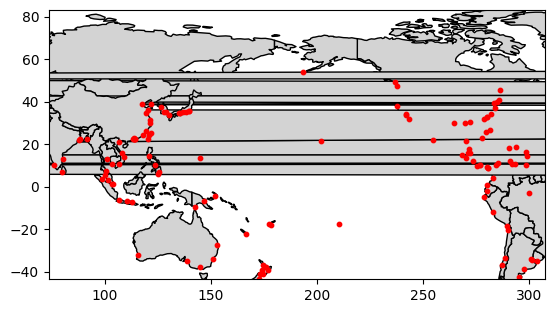

In [7]:
_, _, portpool_Pacific = portpool.plot(pacific, center_pacific=True)

In [8]:
week_demands, unit_revenue = read_demand(portpool_Pacific)
dist_mat = cma.read_sailing_distance_data(portpool_Pacific)

In [9]:
# create a new pool of ports with richer information
portgraph = cma.PortGraph(portpool_Pacific, dist_mat, week_demands, unit_revenue)
num_ports = portgraph.get_number_of_ports()
print(f'In total {num_ports} have freight demand')
portgraph

In total 45 have freight demand


[CNSHA, VNDAD, SGSIN, CNLYG, JPSMZ, VNHPH, USHNL, CAVAN, USOAK, SVAQJ, THLCH, MYPEN, IDSRG, USSEA, KRPUS, VNSGN, GUGUM, USLGB, CNDLC, MYPKG, IDSUB, TWKEL, MXLZC, JPNGO, USLAX, TWKHH, CNXMN, JPTYO, NICIO, JPUKB, PHGES, IDJKT, CNTAO, MYTPP, JPOSA, PHMNL, USDUT, PABLB, CNYTN, CNFOC, HKHKG, JPYOK, PAMIT, JPHKT, MXESE]

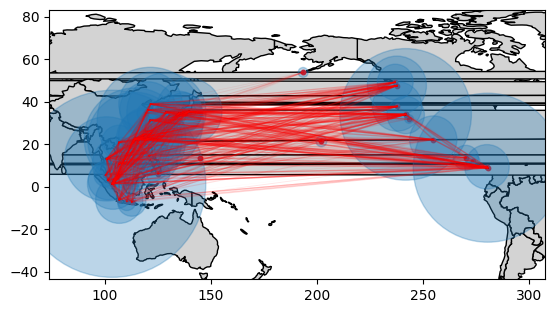

In [10]:
# plot the demands between ports
_, ax, _ = portgraph.plot(pacific, center_pacific=True)

In [11]:
from cma import ServiceGraph, create_service_line

line_1 = create_service_line('line 1', benchutils.line_1_idlst, portpool)
line_2 = create_service_line('line 2', benchutils.line_2_idlst, portpool)
line_3 = create_service_line('line 3', benchutils.line_3_idlst, portpool)
line_4 = create_service_line('line 4', benchutils.line_4_idlst, portpool)
line_5 = create_service_line('line 5', benchutils.line_5_idlst, portpool)
line_6 = create_service_line('line 6', benchutils.line_6_idlst, portpool)
line_7 = create_service_line('line 7', benchutils.line_7_idlst, portpool)
line_8 = create_service_line('line 8', benchutils.line_8_idlst, portpool)
line_9 = create_service_line('line 9', benchutils.line_9_idlst, portpool)
line_10 = create_service_line('line 10', benchutils.line_10_idlst, portpool)
line_11 = create_service_line('line 11', benchutils.line_11_idlst, portpool)
line_12 = create_service_line('line 12', benchutils.line_12_idlst, portpool)
line_13 = create_service_line('line 13', benchutils.line_13_idlst, portpool)
line_14 = create_service_line('line 14', benchutils.line_14_idlst, portpool)
line_15 = create_service_line('line 15', benchutils.line_15_idlst, portpool)
line_16 = create_service_line('line 16', benchutils.line_16_idlst, portpool)
line_17 = create_service_line('line 17', benchutils.line_17_idlst, portpool)

init_service_lines = [line_1, line_2, line_3, line_4, line_5, line_6, line_7, line_8, line_9,
	line_10, line_11, line_12, line_13, line_14, line_15, line_16, line_17]
init_service_graph = ServiceGraph(init_service_lines)

In [12]:
line_3.get_distance(portgraph)

np.float64(21903.15)

In [13]:
# solve the optimal demand fulfillment
sol = init_service_graph.solve_approximated(portgraph, vessel_pool, None, min_cost=False)
init_service_graph.total_profit()

/Users/zhuanglinsheng/Documents/Github/nus_cma_project/.venv/lib/python3.13/site-packages/cvxpy/problems/problem.py:167: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  warnings.warn("Objective contains too many subexpressions. "


np.float64(769234576.7465281)

In [14]:
line_weeks = sol['weeks']
ship_vars = sol['ships']
line_capacities = sol['capacities']

print('Line Name', ' \t', 'distance', '\t', 'week', '\t', 'ships', '\t\t\t', 'capacities')
for line, week, line_ships, line_cap in zip(init_service_lines, line_weeks, ship_vars, line_capacities):
	line_ships_val = [int(ship.value) for ship in line_ships]
	print(
		line.name(), ' \t',
		int(line.get_distance(portgraph)), '\t\t',
		week, '\t',
		line_ships_val, '\t',
		line_cap.value)

Line Name  	 distance 	 week 	 ships 			 capacities
line 1  	 9688 		 5 	 [0, 0, 0, 3, 0, 0] 	 7200.0
line 2  	 30411 		 13 	 [0, 0, 0, 9, 0, 0] 	 21600.0
line 3  	 21903 		 10 	 [0, 9, 0, 0, 0, 0] 	 7200.0
line 4  	 5723 		 3 	 [0, 0, 0, 2, 0, 0] 	 4800.0
line 5  	 30581 		 14 	 [0, 0, 0, 9, 0, 0] 	 21600.0
line 6  	 13466 		 6 	 [0, 0, 0, 5, 0, 0] 	 12000.0
line 7  	 16129 		 7 	 [0, 0, 0, 6, 0, 0] 	 14400.0
line 8  	 5708 		 3 	 [0, 0, 0, 1, 0, 0] 	 2400.0
line 9  	 3395 		 2 	 [0, 1, 0, 0, 0, 0] 	 800.0
line 10  	 4034 		 2 	 [0, 1, 0, 0, 0, 0] 	 800.0
line 11  	 13594 		 6 	 [0, 6, 0, 0, 0, 0] 	 4800.0
line 12  	 18840 		 9 	 [0, 1, 0, 4, 0, 0] 	 10400.0
line 13  	 2581 		 2 	 [0, 1, 0, 0, 0, 0] 	 800.0
line 14  	 9103 		 4 	 [0, 0, 0, 1, 0, 0] 	 2400.0
line 15  	 8945 		 4 	 [0, 0, 0, 1, 0, 0] 	 2400.0
line 16  	 9740 		 5 	 [0, 0, 0, 1, 0, 0] 	 2400.0
line 17  	 992 		 1 	 [1, 0, 0, 0, 0, 0] 	 450.0


In [15]:
# flow_sol = sol['line flows']

# for line_seg_flow in flow_sol:
# 	for y_ij in line_seg_flow:
# 		print(y_ij, '=', y_ij.value)

In [16]:
demand_rounts = sol['demand rounts']
trans_ports = portgraph.filtered_by_transship_capacity()
print(len(trans_ports))
od_pairs_dict = init_service_graph.get_all_paths(portgraph, trans_ports)
od_pairs = od_pairs_dict['od_pairs']
od_pairs_paths = od_pairs_dict['od_pairs_path']
od_pairs_demand = od_pairs_dict['od_pairs_demand']
total_demand = 0
total_accepted_demand = 0

for x_od, od, od_demand, od_ps in zip(demand_rounts, od_pairs, od_pairs_demand, od_pairs_paths):
	accepted_demand = 0
	for x_od_p, od_p in zip(x_od, od_ps):
		if x_od_p.value > 0:
			accepted_demand += x_od_p.value
	total_demand += od_demand
	total_accepted_demand += accepted_demand
	print('from', od[0], 'to', od[1], ' demand =', od_demand, ' fulfilled =', accepted_demand)

print('total demand =', total_demand)
print('fulfilled demand =', total_accepted_demand, '(', 100 * total_accepted_demand / total_demand, '%)')

24
from 42 to 37  demand = 2938.0  fulfilled = 270.0
from 41 to 33  demand = 2241.0  fulfilled = 506.0
from 40 to 37  demand = 1817.0  fulfilled = 444.0
from 40 to 33  demand = 1739.0  fulfilled = 1066.0
from 40 to 24  demand = 1219.0  fulfilled = 673.0
from 38 to 37  demand = 1202.0  fulfilled = 0
from 38 to 33  demand = 1147.0  fulfilled = 0
from 41 to 24  demand = 1066.0  fulfilled = 247.0
from 38 to 24  demand = 866.0  fulfilled = 0
from 38 to 13  demand = 857.0  fulfilled = 267.0
from 37 to 42  demand = 823.0  fulfilled = 276.0
from 37 to 40  demand = 715.0  fulfilled = 272.0
from 37 to 33  demand = 673.0  fulfilled = 597.0
from 37 to 0  demand = 507.0  fulfilled = 388.0
from 33 to 40  demand = 506.0  fulfilled = 507.0
from 33 to 37  demand = 444.0  fulfilled = 0
from 32 to 37  demand = 403.0  fulfilled = 283.0
from 32 to 33  demand = 388.0  fulfilled = 403.0
from 32 to 24  demand = 380.0  fulfilled = 267.0
from 26 to 33  demand = 376.0  fulfilled = 346.0
from 24 to 40  demand = 3